In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from pathlib import Path
import napari

# ==========================================
# 0. PRE-PROCESSING UTILITIES
# ==========================================
def apply_db_cutoff(vol, cutoff_db=-5):
    """
    Zeros out voxels more than 'cutoff_db' below the peak.
    Returns the thresholded volume and the sparsity percentage.
    """
    v_abs = np.abs(vol)
    v_max = np.max(v_abs)
    if v_max == 0:
        return vol, 0.0
    
    # Linear threshold = Vmax * 10^(dB / 20)
    thresh = v_max * (10**(cutoff_db / 20))
    
    # Create mask and apply
    v_thresh = np.where(v_abs >= thresh, vol, 0)
    
    # Calculate how much of the volume is now zeros
    sparsity = (np.count_nonzero(v_thresh == 0) / v_thresh.size) * 100
    return v_thresh.astype(np.float32), sparsity

# ==========================================
# 1. THE STITCHER ENGINE (Profile-Based Consensus)
# ==========================================
def run_stitcher_test(vol1, vol2, axis=2, grid=(60, 20), expected=0, tolerance=200, cutoff_db=-5):
    v1, s1 = apply_db_cutoff(vol1, cutoff_db)
    v2, s2 = apply_db_cutoff(vol2, cutoff_db)
    
    print(f"[Pre-Process] Applied {cutoff_db}dB Cutoff.")
    print(f" -> Vol1 Sparsity: {s1:.1f}% | Vol2 Sparsity: {s2:.1f}%")

    ignore_top = 30
    z_dim, y_dim, x_dim = v1.shape
    z_start, z_end = ignore_top, z_dim
    
    tile_z = (z_end - z_start) // grid[0]
    tile_y = y_dim // grid[1]
    
    all_shifts = []
    all_weights = []
    
    for r in range(grid[0]):
        for c in range(grid[1]):
            zs, ze = z_start + (r * tile_z), z_start + ((r + 1) * tile_z)
            ys, ye = c * tile_y, (c + 1) * tile_y
            
            prof1 = np.max(np.abs(v1[zs:ze, ys:ye, :]), axis=(0, 1))
            prof2 = np.max(np.abs(v2[zs:ze, ys:ye, :]), axis=(0, 1))

            if np.std(prof1) < 1e-6 or np.max(prof1) == 0:
                continue

            p1_n = (prof1 - np.mean(prof1)) / (np.std(prof1) + 1e-10)
            p2_n = (prof2 - np.mean(prof2)) / (np.std(prof2) + 1e-10)
            
            corr = correlate(p1_n, p2_n, mode='full')
            lags = correlation_lags(len(p1_n), len(p2_n), mode='full')
            
            mask = (lags >= expected - tolerance) & (lags <= expected + tolerance)
            if not np.any(mask): continue
            corr[~mask] = -np.inf 

            peak_idx = np.argmax(corr)
            all_shifts.append(lags[peak_idx])
            all_weights.append(corr[peak_idx])

    if not all_shifts:
        raise ValueError(f"No features survived the {cutoff_db}dB cutoff.")

    lag_min, lag_max = np.min(all_shifts), np.max(all_shifts)
    bins = np.arange(lag_min, lag_max + 2) - 0.5
    counts, bin_edges = np.histogram(all_shifts, bins=bins, weights=all_weights)
    final_shift = int(bin_edges[np.argmax(counts)] + 0.5)

    print(f"\n Shift: {final_shift} voxels")
    
    return final_shift, v1

# ==========================================
# 2. STANDALONE STITCHER EXECUTION
# ==========================================
if __name__ == "__main__":
    IN_DIR = Path.cwd().parent / 'DATA' / '2D TFM Data' / 'FeC Smile 3MHz 04022026 Filtered'
    
    try:
        vol1_raw = np.load(IN_DIR / "FeC_40_5_filtered_3D_TFM.npy")
        vol2_raw = np.load(IN_DIR / "FeC_40_6_filtered_3D_TFM.npy")
    except FileNotFoundError:
        print("Data not found.")
        exit()

    stitch_shift, v1_thresholded = run_stitcher_test(vol1_raw, vol2_raw, grid=(120, 40), cutoff_db=-5)

    # --- THE FIX: ROBUST CONTRAST LIMITS ---
    # Raw Data Limits
    clim_raw = sorted([float(np.percentile(vol1_raw, 0.1)), float(np.percentile(vol1_raw, 99.9))])
    if clim_raw[0] == clim_raw[1]: clim_raw = [clim_raw[0], clim_raw[0] + 1]

    # Thresholded Data Limits
    clim_thresh = sorted([float(np.min(v1_thresholded)), float(np.max(v1_thresholded))])
    if clim_thresh[0] == clim_thresh[1]: clim_thresh = [0, 1]

    viewer = napari.Viewer(title="Stitcher Result Testing (-5dB Cutoff)")

    # Layer 1: Raw Reference
    viewer.add_image(vol1_raw, name='Vol 1 (Raw)', colormap='cyan', contrast_limits=clim_raw, opacity=0.5)
    
    # Layer 2: The Hotspots (Sorted clim ensures no monotonically increasing error)
    viewer.add_image(v1_thresholded, name='Vol 1 (-5dB Hotspots)', colormap='yellow', contrast_limits=clim_thresh)

    # Layer 3: The shifted Volume 2
    trans = [0, 0, 0]; trans[2] = stitch_shift
    viewer.add_image(vol2_raw, name=f'Vol 2 (Shifted {stitch_shift}px)', 
                     colormap='magenta', blending='additive', translate=trans, contrast_limits=clim_raw)

    print(f"\nStitcher complete. Threshold limits used: {clim_thresh}")
    napari.run()

[Pre-Process] Applied -5dB Cutoff.
 -> Vol1 Sparsity: 0.3% | Vol2 Sparsity: 0.3%

 Shift: -55 voxels

Stitcher complete. Threshold limits used: [-10.0, 0.0]


Starting SSIM Brute-Force (Range: (0, 200))...
 Processing shift 0...
 Processing shift 20...
 Processing shift 40...
 Processing shift 60...
 Processing shift 80...
 Processing shift 100...
 Processing shift 120...
 Processing shift 140...
 Processing shift 160...
 Processing shift 180...

[SSIM Complete] Best Shift: 174 (Score: 0.9253)


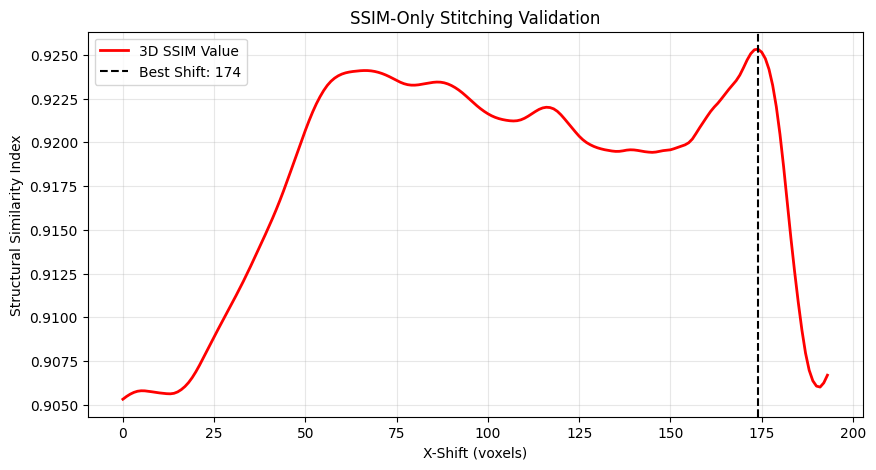

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import napari
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 1. THE SSIM STITCHER ENGINE
# ==========================================
def run_ssim_stitcher(vol1, vol2, ignore_z=30, search_range=(350, 550)):
    """
    Finds the optimal stitch shift by calculating 3D SSIM 
    across a range of possible X-offsets.
    """
    # Crop top noise (surface reflections) as before
    v1 = vol1[ignore_z:, :, :]
    v2 = vol2[ignore_z:, :, :]
    
    x1_dim = v1.shape[2]
    x2_dim = v2.shape[2]
    
    # SSIM requires the dynamic range of the data
    data_range = max(v1.max(), v2.max()) - min(v1.min(), v2.min())
    
    lags = []
    ssim_scores = []

    print(f"Starting SSIM Brute-Force (Range: {search_range})...")

    for shift in range(search_range[0], search_range[1]):
        # Calculate the length of the overlapping 3D section
        overlap_len = min(x1_dim - shift, x2_dim)
        
        if overlap_len < 7: # SSIM needs a minimum window size
            continue

        # Extract the overlapping 3D 'bricks' at corresponding positions
        # Vol1's tail vs Vol2's head
        brick1 = v1[:, :, shift : shift + overlap_len]
        brick2 = v2[:, :, 0 : overlap_len]

        # Calculate 3D Structural Similarity
        # win_size=3 provides high-resolution local structural checking
        score = ssim(brick1, brick2, data_range=data_range, win_size=3)
        
        lags.append(shift)
        ssim_scores.append(score)

        if shift % 20 == 0:
            print(f" Processing shift {shift}...")

    lags = np.array(lags)
    ssim_scores = np.array(ssim_scores)
    
    # The winner is the shift with the absolute highest structural similarity
    best_shift = lags[np.argmax(ssim_scores)]
    
    print(f"\n[SSIM Complete] Best Shift: {best_shift} (Score: {np.max(ssim_scores):.4f})")
    return best_shift, lags, ssim_scores

# ==========================================
# 2. EXECUTION
# ==========================================
if __name__ == "__main__":
    # Define Data Directory
    IN_DIR = Path.cwd().parent / 'DATA' / '2D TFM Data' / 'FeC Smile 3MHz 04022026 Filtered Old'
    
    try:
        vol1_raw = np.load(IN_DIR / "FeC_40_6_filtered_3D_TFM.npy")
        vol2_raw = np.load(IN_DIR / "FeC_40_5_filtered_3D_TFM.npy")
    except FileNotFoundError:
        print("Data not found. Check your file paths.")
        exit()

    # 1. Run SSIM-based Stitching
    # Note: Search range adjusted based on your expected overlap
    stitch_shift, all_lags, all_ssim = run_ssim_stitcher(
        vol1_raw, vol2_raw, 
        ignore_z=30, 
        search_range=(0, 200) 
    )

    # 2. Plot SSIM vs Shift
    plt.figure(figsize=(10, 5))
    plt.plot(all_lags, all_ssim, color='red', linewidth=2, label='3D SSIM Value')
    plt.axvline(x=stitch_shift, color='black', linestyle='--', label=f'Best Shift: {stitch_shift}')
    plt.title("SSIM-Only Stitching Validation")
    plt.xlabel("X-Shift (voxels)")
    plt.ylabel("Structural Similarity Index")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # 3. Visualization in Napari
    viewer = napari.Viewer(title=f"SSIM Optimized Stitch (Shift: {stitch_shift})")

    # Set robust contrast limits based on percentiles for visualization
    clim = [float(np.percentile(vol1_raw, 1)), float(np.percentile(vol1_raw, 99))]

    viewer.add_image(vol1_raw, name='Volume 1', colormap='gray', contrast_limits=clim)
    
    # Translate Volume 2 by the SSIM-calculated shift
    trans = [0, 0, stitch_shift]
    viewer.add_image(vol2_raw, name=f'Volume 2 (Shifted {stitch_shift})', 
                     colormap='magenta', blending='additive', translate=trans, contrast_limits=clim)

    napari.run()